**Importing libraries**

In [44]:
print("Importing libraries...")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn.metrics as skm
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV,
    RandomizedSearchCV
)
print("Libraries imported successfully.")

Importing libraries...
Libraries imported successfully.


**Importing models**

In [43]:
print("Importing models")
from sklearn.preprocessing import (
    StandardScaler,
)
from sklearn.pipeline import Pipeline
from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet
)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)
from sklearn.svm import SVR
import xgboost as xgb
print("Importing models completed")

Importing models
Importing models completed


**Importing Model saving module**

In [45]:
print("Importing Model saving module")
import joblib
print("Importing Model saving module has finished")

Importing Model saving module
Importing Model saving module has finished


**Importing Debugging modules**

In [47]:
import time
import logging
import platform
import os
from datetime import datetime
import psutil

In [48]:
# ===========================================
# Runtime & Logging
# ===========================================

start_time = time.time()
start_datetime = datetime.now()

logging.basicConfig(
    filename="training.log",
    level=logging.INFO,
    format="%(asctime)s - %(message)s"
)

print("="*60)
print("USED CAR PRICE PREDICTOR")
print("="*60)

print("Program Started:", start_datetime)
logging.info("Program Started")

print("\nSystem Information")
print("-----------------------")
print("Operating System :", platform.system())
print("OS Version       :", platform.version())
print("Processor        :", platform.processor())
print("CPU Cores        :", os.cpu_count())

memory = psutil.virtual_memory()

print(f"RAM              : {memory.total/1024**3:.2f} GB")
print(f"RAM Usage        : {memory.percent}%")

logging.info("System Information Printed")

USED CAR PRICE PREDICTOR
Program Started: 2026-07-14 13:36:34.828314

System Information
-----------------------
Operating System : Windows
OS Version       : 10.0.19045
Processor        : Intel64 Family 6 Model 69 Stepping 1, GenuineIntel
CPU Cores        : 4
RAM              : 7.91 GB
RAM Usage        : 68.0%


**Importing data**

In [49]:
data = pd.read_csv(r"C:\Users\Syed\Desktop\used car price predictor\car_prices_3.csv")

**Step 1 : EDA**

In [50]:
print(data.head(7))

  COMPANY                MODEL        TYPE   SIZE transmission state  \
0     Kia              Sorento          LX    SUV    automatic    ca   
1     Kia              Sorento          LX    SUV    automatic    ca   
2     BMW             3 Series  328i SULEV  Sedan    automatic    ca   
3   Volvo                  S60          T5  Sedan    automatic    ca   
4     BMW  6 Series Gran Coupe        650i  Sedan    automatic    ca   
5  Nissan               Altima       2.5 S  Sedan    automatic    ca   
6     BMW                   M5        Base  Sedan    automatic    ca   

   condition  odometer  color interior  \
0        5.0   16639.0  white    black   
1        5.0    9393.0  white    beige   
2       45.0    1331.0   gray    black   
3       41.0   14282.0  white    black   
4       43.0    2641.0   gray    black   
5        1.0    5554.0   gray    black   
6       34.0   14943.0  black    black   

                                              seller      mmr  sellingprice  \
0      

In [51]:
print("EDA has begun")
print("")
print("data columns:")
for cols in data.columns:
    print(cols)
print("")
print("First 5 entries of the dataset")
print(data.head(5))
print(data.info())
print("")
print("no of rows:", data.shape[0])
print("no of columns:", data.shape[1])
print("")
for i in data.columns:
    print(f"column name: {i},\n data type: {data[i].dtype}, \n no of unique values: {data[i].nunique()}")
    print("")
print("EDA has ended")

EDA has begun

data columns:
COMPANY
MODEL
TYPE
SIZE
transmission
state
condition
odometer
color
interior
seller
mmr
sellingprice
sale Day
Sale month
Sale year

First 5 entries of the dataset
  COMPANY                MODEL        TYPE   SIZE transmission state  \
0     Kia              Sorento          LX    SUV    automatic    ca   
1     Kia              Sorento          LX    SUV    automatic    ca   
2     BMW             3 Series  328i SULEV  Sedan    automatic    ca   
3   Volvo                  S60          T5  Sedan    automatic    ca   
4     BMW  6 Series Gran Coupe        650i  Sedan    automatic    ca   

   condition  odometer  color interior  \
0        5.0   16639.0  white    black   
1        5.0    9393.0  white    beige   
2       45.0    1331.0   gray    black   
3       41.0   14282.0  white    black   
4       43.0    2641.0   gray    black   

                                   seller      mmr  sellingprice sale Day  \
0                 kia motors america  inc  20

**Step 2 : Data cleaning**

In [52]:
print("Data cleaning has begun...")

# Remove missing values
data = data.dropna()

# Remove duplicate rows
data = data.drop_duplicates()

# Drop high-cardinality and unnecessary columns
data.drop(columns=["seller", "TYPE"], inplace=True)

print("Data cleaning has ended.")

Data cleaning has begun...
Data cleaning has ended.


**Step 3 : Feature engineering**

In [53]:
print("Feature engineering has begun...")

# No meaningful feature engineering can be performed because
# the dataset does not contain the manufacturing year.

print("No additional features were created.")
print("Feature engineering has ended.")

Feature engineering has begun...
No additional features were created.
Feature engineering has ended.


**Step 4 : encoding**

In [54]:
print("Encoding has begun...")

# Keep only the 200 most common models
top_models = data["MODEL"].value_counts().nlargest(200).index
data["MODEL"] = data["MODEL"].where(
    data["MODEL"].isin(top_models),
    "Other"
)

# One-Hot Encode all categorical columns
categorical_columns = [
    "COMPANY",
    "MODEL",
    "SIZE",
    "transmission",
    "state",
    "color",
    "interior",
    "sale Day",
    "Sale month"
]

data = pd.get_dummies(
    data,
    columns=categorical_columns,
    drop_first=True,
    dtype=int
)

print("Encoding completed.")
print("Dataset shape:", data.shape)

Encoding has begun...
Encoding completed.
Dataset shape: (440393, 420)


**Step 5 : Train_test_split**

In [55]:
data_train,data_test=train_test_split( data, test_size=0.2, random_state=42)
X_train = data_train.drop("sellingprice", axis = 1)
y_train = data_train["sellingprice"]
X_test = data_test.drop("sellingprice", axis = 1)
y_test = data_test["sellingprice"]

**Step 6 : Scaling**

In [56]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [59]:
print("Dumping the preprocessing")
joblib.dump(X_train.columns.tolist(), "feature_columns.pkl")
joblib.dump(top_models.tolist(), "top_models.pkl")
joblib.dump(categorical_columns, "categorical_columns.pkl")
joblib.dump(scaler, "scaler.pkl")

Dumping the preprocessing


['scaler.pkl']

**Step 7 : Train 9 Models**

**Here are the models to train:**

* **Linear Regression**
* **Ridge Regression**
* **Lasso Regression**
* **Elastic Net**
* **KNN Regressor**
* **Decision Tree Regressor**
* **SVR**
* **Gradient Boosting Regressor**
* **XGBoost Regressor**

In [14]:
print("\n" + "="*60)
print("Step 7 : Model training")
print("="*60)

logging.info("Model training Started")

step_start = time.time()


Step 7 : Model training


In [15]:
linear_regression = LinearRegression()
linear_regression.fit(X_train_scaled, y_train)
LinearRegression_model = linear_regression.predict(X_test_scaled)

In [16]:
rig_reg = Ridge()
rig_reg.fit(X_train_scaled, y_train)
RidgeRegression_model = rig_reg.predict(X_test_scaled)

In [17]:
las_reg = Lasso()
las_reg.fit(X_train_scaled, y_train)
LassoRegression_model = las_reg.predict(X_test_scaled)

In [18]:
eln = ElasticNet()
eln.fit(X_train_scaled, y_train)
Elastic_modelNet = eln.predict(X_test_scaled)

In [19]:
knn = KNeighborsRegressor()

Knn_subset_size = 50000
X_train_scaled_knn = X_train_scaled[:Knn_subset_size]
y_train_knn = y_train[:Knn_subset_size]
X_test_scaled_knn = X_test_scaled[:Knn_subset_size]
y_test_knn = y_test[:Knn_subset_size]

knn.fit(X_train_scaled_knn, y_train_knn)

KNN_model = knn.predict(X_test_scaled_knn)

In [20]:
dtr = DecisionTreeRegressor()
dtr.fit(X_train, y_train)
DecisionTree_model = dtr.predict(X_test)

In [21]:
svm=SVR()

SVR_subset_size = 5000
X_train_scaled_svm = X_train_scaled[:SVR_subset_size]
y_train_svm = y_train[:SVR_subset_size]
X_test_scaled_svm = X_test_scaled[:SVR_subset_size]
y_test_svm = y_test[:SVR_subset_size]

svm.fit(X_train_scaled_svm, y_train_svm)

SVR_model = svm.predict(X_test_scaled_svm)


In [22]:
gbr=GradientBoostingRegressor()
gbr.fit(X_train, y_train)
GBR_model = gbr.predict(X_test)

In [23]:
xgbost = xgb.XGBRegressor()
xgbost.fit(X_train, y_train)
XGB_model = xgbost.predict(X_test)

In [24]:
step_end = time.time()

print(f"\nModel training completed in {(step_end-step_start)/60:.2f} minutes")

logging.info(
    f"Model training completed in {(step_end-step_start)/60:.2f} minutes"
)


Model training completed in 13.94 minutes


**Step 8 : Evaluation**

In [25]:
print("All models have been trained and predictions have been made to show the performance of the model, we will print the regression report and confusion matrix.")

def evaluation(report_name, test_y, pred_y):

    MAE = skm.mean_absolute_error(test_y, pred_y)
    MSE = skm.mean_squared_error(test_y, pred_y)
    RMSE = np.sqrt(MSE)
    R2 = skm.r2_score(test_y, pred_y)

    return pd.DataFrame({
        "Report": [report_name],
        "MAE": [MAE],
        "MSE": [MSE],
        "RMSE": [RMSE],
        "R2 Score": [R2]
    })

reports = pd.concat([
evaluation("Linear Regression", y_test, LinearRegression_model),
evaluation("Ridge Regression", y_test, RidgeRegression_model),
evaluation("Lasso Regression", y_test, LassoRegression_model),
evaluation("Elastic Net Regression", y_test, Elastic_modelNet),
evaluation("Decision Tree Regression", y_test, DecisionTree_model),
evaluation("KNN Regression", y_test_knn, KNN_model),
evaluation("SVR", y_test_svm, SVR_model),
evaluation("Gradient Boosting", y_test, GBR_model),
evaluation("XGBoost", y_test, XGB_model)
], ignore_index=True)

reports = reports.sort_values(
    by=["R2 Score", "RMSE", "MAE"],
    ascending=[False, True, True]
).reset_index(drop=True)
placeholdersp1 = ["First","Second","Third","4","5","6","7","8","9"]
reports.index = placeholdersp1

reports.to_csv("model_comparison.csv", index=False)

reports

All models have been trained and predictions have been made to show the performance of the model, we will print the regression report and confusion matrix.


,Report,MAE,MSE,RMSE,R2 Score
First,Gradient Boosting,940.970606,2.150396e+06,1466.422929,0.976300
Second,Lasso Regression,1017.631917,2.531240e+06,1590.987135,0.972103
Third,Ridge Regression,1018.380228,2.534219e+06,1591.923057,0.972070
4,Linear Regression,1018.379089,2.534225e+06,1591.924803,0.972070
5,XGBoost,927.896444,2.805514e+06,1674.966763,0.969080
6,Decision Tree Regression,1283.402684,4.329956e+06,2080.854707,0.952279
7,Elastic Net Regression,2046.142598,1.028727e+07,3207.376833,0.886622
8,KNN Regression,3898.049888,3.284344e+07,5730.919713,0.640172
9,SVR,6821.801749,8.861695e+07,9413.657427,-0.015524


**Step 9 : Pick 2-3 best models**

In [26]:
print("""According to the table,
the best model is Gradient Boosting regression,
followed by Lasso regression,
and at the third comes Ridge regression,""")
print("so we will hyperparameter tune the 3 winning models")

According to the table,
the best model is Gradient Boosting regression,
followed by Lasso regression,
and at the third comes Ridge regression,
so we will hyperparameter tune the 3 winning models


**Step 10 : Cross Validation**

In [27]:
print("\n" + "="*60)
print("Step 10 : Cross Validation")
print("="*60)

logging.info("Cross Validation Started")

step_start = time.time()


Step 10 : Cross Validation


In [28]:
gbr_cv = cross_val_score(
    gbr,
    X_train,
    y_train.values.ravel(),
    cv=5,
    scoring="r2",
    n_jobs=-1
)

print("Gradient Boosting")
print(gbr_cv)
print("Average R²:", np.mean(gbr_cv))

Lasso_cv = cross_val_score(
    las_reg,
    X_train_scaled,
    y_train.values.ravel(),
    cv=5,
    scoring="r2",
    n_jobs=-1
)

print("Lasso regression")
print(Lasso_cv)
print("Average R²:", np.mean(Lasso_cv))

Ridge_cv = cross_val_score(
    rig_reg,
    X_train_scaled,
    y_train.values.ravel(),
    cv=5,
    scoring="r2",
    n_jobs=-1
)

print("Ridge Regression")
print(Ridge_cv)
print("Average R²:", np.mean(Ridge_cv))

Gradient Boosting
[0.97493947 0.97688934 0.96941746 0.97566929 0.97492598]
Average R²: 0.9743683088246424
Lasso regression
[0.97100308 0.97233064 0.96550884 0.97107853 0.97036081]
Average R²: 0.9700563815651033
Ridge Regression
[0.97103783 0.97235629 0.96546689 0.97113966 0.97035376]
Average R²: 0.9700708868401007


In [29]:
step_end = time.time()

print(f"\nCross Validation completed in {(step_end-step_start)/60:.2f} minutes")

logging.info(
    f"Cross Validation completed in {(step_end-step_start)/60:.2f} minutes"
)


Cross Validation completed in 38.93 minutes


**Step 11 : Hyperparameter Tuning**

In [30]:
print("\n" + "="*60)
print("Step 11 : Hyperparameter Tuning")
print("="*60)

logging.info("Hyperparameter Tuning Started")

step_start = time.time()


Step 11 : Hyperparameter Tuning


In [31]:
print("Ridge regression:")
ridge_params = {
    "alpha": [0.001, 0.01, 0.1, 1, 10, 100]
}

ridge_search = GridSearchCV(
    estimator=rig_reg,
    param_grid=ridge_params,
    scoring="r2",
    cv=5,
    n_jobs=-1
)

ridge_search.fit(X_train_scaled, y_train.values.ravel())

print("Best Parameters:", ridge_search.best_params_)
print("Best Score:", ridge_search.best_score_)
print("Best Model:", ridge_search.best_estimator_)

print("Lasso regression")
lasso_params = {
    "alpha": [0.001, 0.01, 0.1, 1, 10, 100]
}

lasso_search = GridSearchCV(
    estimator=las_reg,
    param_grid=lasso_params,
    scoring="r2",
    cv=5,
    n_jobs=-1
)

lasso_search.fit(X_train_scaled, y_train.values.ravel())

print("Best Parameters:", lasso_search.best_params_)
print("Best Score:", lasso_search.best_score_)
print("Best Model:", lasso_search.best_estimator_)

print("Gradient boosting regression")
gbr_params = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [3, 5],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

gbr_search = RandomizedSearchCV(
    estimator=gbr,
    param_distributions=gbr_params,
    n_iter=10,
    scoring="r2",
    cv=5,
    random_state=42,
    n_jobs=-1
)

gbr_search.fit(X_train, y_train.values.ravel())

print("Best Parameters:", gbr_search.best_params_)
print("Best Score:", gbr_search.best_score_)
print("Best Model:", gbr_search.best_estimator_)


Ridge regression:
Best Parameters: {'alpha': 10}
Best Score: 0.9700709845934424
Best Model: Ridge(alpha=10)
Lasso regression
Best Parameters: {'alpha': 0.1}
Best Score: 0.9700723537478215
Best Model: Lasso(alpha=0.1)
Gradient boosting regression
Best Parameters: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 5, 'learning_rate': 0.1}
Best Score: 0.9761741271439652
Best Model: GradientBoostingRegressor(max_depth=5, min_samples_leaf=2, n_estimators=200)


In [32]:
step_end = time.time()

print(f"\nHyperparameter Tuning completed in {(step_end-step_start)/60:.2f} minutes")

logging.info(
    f"Hyperparameter Tuning completed in {(step_end-step_start)/60:.2f} minutes"
)


Hyperparameter Tuning completed in 614.26 minutes


In [33]:
logging.info("Saving trained model")

In [34]:
print("Saving the Hyperparameters")
best_gbr = gbr_search.best_estimator_
best_ridge = ridge_search.best_estimator_
best_lasso = lasso_search.best_estimator_

print("Saving models...")
joblib.dump(best_gbr, "gradient_boosting_model.pkl")
joblib.dump(best_ridge, "ridge_model.pkl")
joblib.dump(best_lasso, "lasso_model.pkl")
joblib.dump(scaler, "scaler.pkl")
logging.info("All models saved successfully")
print("Successfully Saved")

Saving the Hyperparameters
Saving models...
Successfully Saved


In [35]:
logging.info("Model saved successfully")

In [36]:
print("Best selected model: Gradient Boosting Regresion")

Best selected model: Gradient Boosting Regresion


**Step 12 : Make Final Prediction**

In [37]:
print("Predicting from the best model")
y_pred_final = best_gbr.predict(X_test)

Predicting from the best model


**Step 13 : Final Evaluation**

In [38]:
print("Evaluating")
FINAL_MAE = skm.mean_absolute_error(y_test, y_pred_final)
FINAL_MSE = skm.mean_squared_error(y_test, y_pred_final)
FINAL_RMSE = np.sqrt(FINAL_MSE)
FINAL_R2 = skm.r2_score(y_test, y_pred_final)

print("final MAE:", FINAL_MAE)
print("final MSE:", FINAL_MSE)
print("final RMSE:", FINAL_RMSE)
print("final R2:", FINAL_R2)


Evaluating
final MAE: 896.0585818659163
final MSE: 1981917.1618669424
final RMSE: 1407.8057969290162
final R2: 0.9781569148955789


Feature Importance


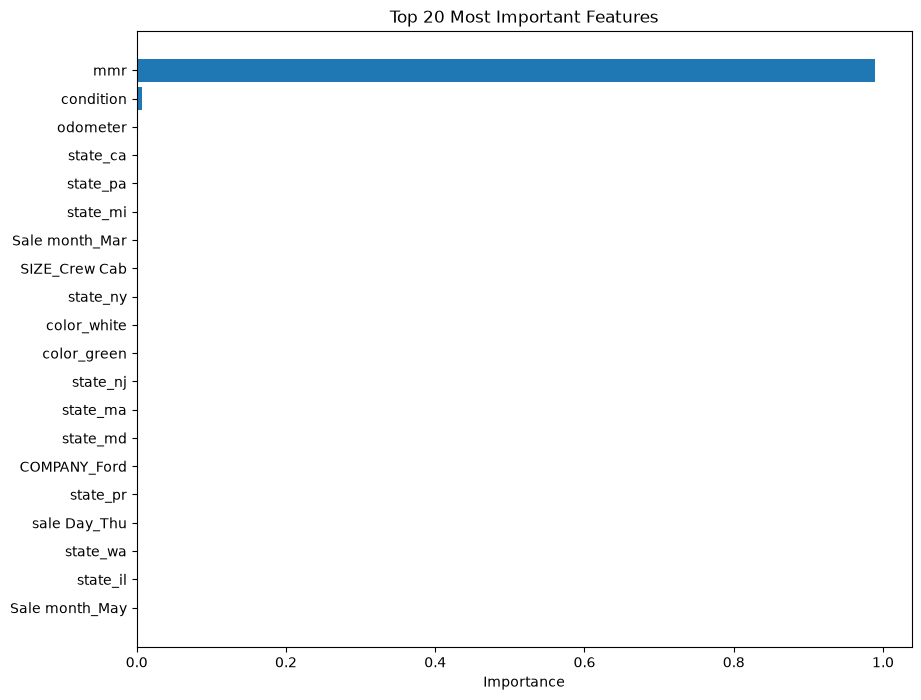

In [39]:
print("Feature Importance")
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_gbr.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,8))
plt.barh(
    feature_importance["Feature"][:20],
    feature_importance["Importance"][:20]
)
plt.title("Top 20 Most Important Features")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.show()

Actual vs Predicted


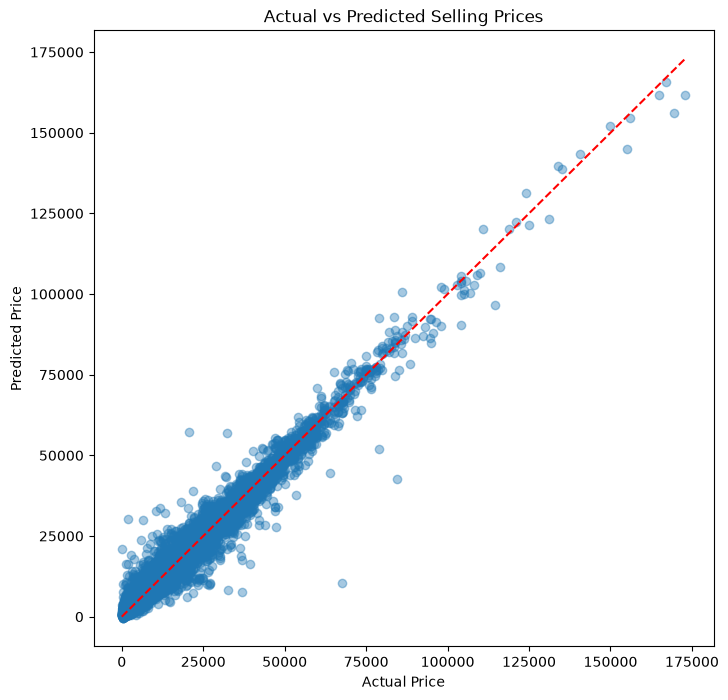

In [ ]:
print("Actual vs Predicted")
plt.figure(figsize=(8,8))
plt.scatter(y_test, y_pred_final, alpha=0.4)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Selling Prices")

plt.show()

**Step 14 : Save the model**

In [41]:
print("Model has already been saved")

Model has already been saved


In [42]:
print("\n" + "="*60)
print("Program Finished")
print("="*60)

end_datetime = datetime.now()
end_time = time.time()

logging.info("Program Finished")

total_time = end_time - start_time

hours = int(total_time // 3600)
minutes = int((total_time % 3600) // 60)
seconds = int(total_time % 60)

print(f"Started : {start_datetime}")
print(f"Finished: {end_datetime}")
print(f"Total Runtime: {hours}h {minutes}m {seconds}s")

logging.info(
    f"Total Runtime: {hours}h {minutes}m {seconds}s"
)


Program Finished
Started : 2026-07-14 01:05:27.348835
Finished: 2026-07-14 12:13:20.204852
Total Runtime: 11h 7m 52s
